# Análise de ROI em Publicidade — Melhores Compras

## tl;dr

- O modelo selecionado foi a **regressão polinomial de grau 2 com efeitos específicos por mídia**, porque apresentou o melhor equilíbrio entre ajuste e generalização.
- Resultado no teste: **R² = 0.9858**, **MAE = 106.20 mil unidades** e **RMSE = 138.80 mil unidades**.
- A validação cruzada de cinco partes resultou em **R² médio = 0.9734 ± 0.0110**.
- Em eficiência observada, **Google** e **Instagram** lideram, mas possuem apenas sete observações cada e aparecem somente em 2024. A recomendação é ampliar o teste antes de deslocar grande parte do orçamento.


## Context & Methods

O objetivo é explicar a previsão de aumento de vendas a partir do investimento, do canal e do período. A variável categórica `Tipo de Midia` é convertida em dummies. O gasto é interagido com cada mídia, permitindo inclinações diferentes. São comparados modelos linear, polinomial de grau 2 e grau 3.

### Key Assumptions

- A coluna-alvo é tratada como **aumento previsto em mil unidades**, conforme o arquivo.
- O termo “ROI” do enunciado é interpretado como eficiência em unidades por investimento; não há receita ou margem incremental para calcular ROI financeiro.
- O teste usa 20% da base com estratificação por mídia; a seleção do grau usa validação cruzada de cinco partes.
- O CSV original é apenas lido; toda transformação ocorre em memória.


## Data

### 1. Imports, parâmetros e localização do arquivo

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42

def localizar_arquivo(nome):
    candidatos = [Path(nome), Path("dados") / nome, Path("/content") / nome]
    for caminho in candidatos:
        if caminho.exists():
            return caminho
    raise FileNotFoundError(f"Coloque {nome} na mesma pasta do notebook ou em ./dados/")

ARQUIVO = localizar_arquivo("Gastos_Publicidade_MelhoresCompras.csv")
print(f"Arquivo localizado: {ARQUIVO.resolve()}")

Arquivo localizado: /workspace/scratch/5eedc3fb7dce/upload/Gastos_Publicidade_MelhoresCompras.csv


### 2. Leitura e validação inicial

In [2]:
dados = pd.read_csv(ARQUIVO)
COL_GASTO = "Gastos com Publicidade (em R$)"
COL_ALVO = "Previsao Inicial de Aumento de Vendas (em mil unidades)"
COL_MIDIA = "Tipo de Midia"

dados[COL_GASTO] = pd.to_numeric(
    dados[COL_GASTO].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)
dados["Ano_c"] = dados["Ano"] - dados["Ano"].min()
dados["Mes_c"] = dados["Mes"] - 1

print(f"Dimensão: {dados.shape[0]} linhas x {dados.shape[1]} colunas")
print(f"Ausências: {int(dados.isna().sum().sum())} | Duplicatas integrais: {int(dados.duplicated().sum())}")
print(f"Período: {dados['Ano'].min()} a {dados['Ano'].max()}")
print("Mídias:", ", ".join(sorted(dados[COL_MIDIA].unique())))
print(dados.head().to_string(index=False))

Dimensão: 200 linhas x 7 colunas
Ausências: 0 | Duplicatas integrais: 0
Período: 2022 a 2024
Mídias: Google, Instagram, Jornal, Paginas web, Radio, Redes sociais, Revista, TV
 Ano  Mes Tipo de Midia  Gastos com Publicidade (em R$)  Previsao Inicial de Aumento de Vendas (em mil unidades)  Ano_c  Mes_c
2022    1   Paginas web                         87000.0                                                     1000      0      0
2022    1 Redes sociais                        120000.0                                                      800      0      0
2022    1            TV                        250000.0                                                     1500      0      0
2022    1        Jornal                        110000.0                                                      730      0      0
2022    1       Revista                         40000.0                                                      360      0      0


### 3. Estatísticas por mídia

In [3]:
resumo_midia = (
    dados.assign(Eficiencia_por_100_mil=dados[COL_ALVO] / dados[COL_GASTO] * 100_000)
    .groupby(COL_MIDIA)
    .agg(
        Observacoes=(COL_ALVO, "size"),
        Gasto_medio=(COL_GASTO, "mean"),
        Aumento_medio=(COL_ALVO, "mean"),
        Eficiencia_media=("Eficiencia_por_100_mil", "mean"),
    )
    .sort_values("Eficiencia_media", ascending=False)
)
print(resumo_midia.round(2).to_string())
print("\nCorrelação simples gasto × aumento:", round(dados[[COL_GASTO, COL_ALVO]].corr().iloc[0,1], 4))

               Observacoes  Gasto_medio  Aumento_medio  Eficiencia_media
Tipo de Midia                                                           
Google                   7    139285.71        4500.00           3230.77
Instagram                7    179614.29        4898.57           2727.27
Paginas web             31    152042.99        1983.42           1311.04
Revista                 31     81141.16         833.00           1024.16
Radio                   31     96909.88         884.00            940.86
Redes sociais           31    195459.10        1721.26            853.54
Jornal                  31    143672.31        1219.13            818.61
TV                      31    266192.71        1916.68            714.26

Correlação simples gasto × aumento: 0.5647


## Results

### 4. Matriz de correlação

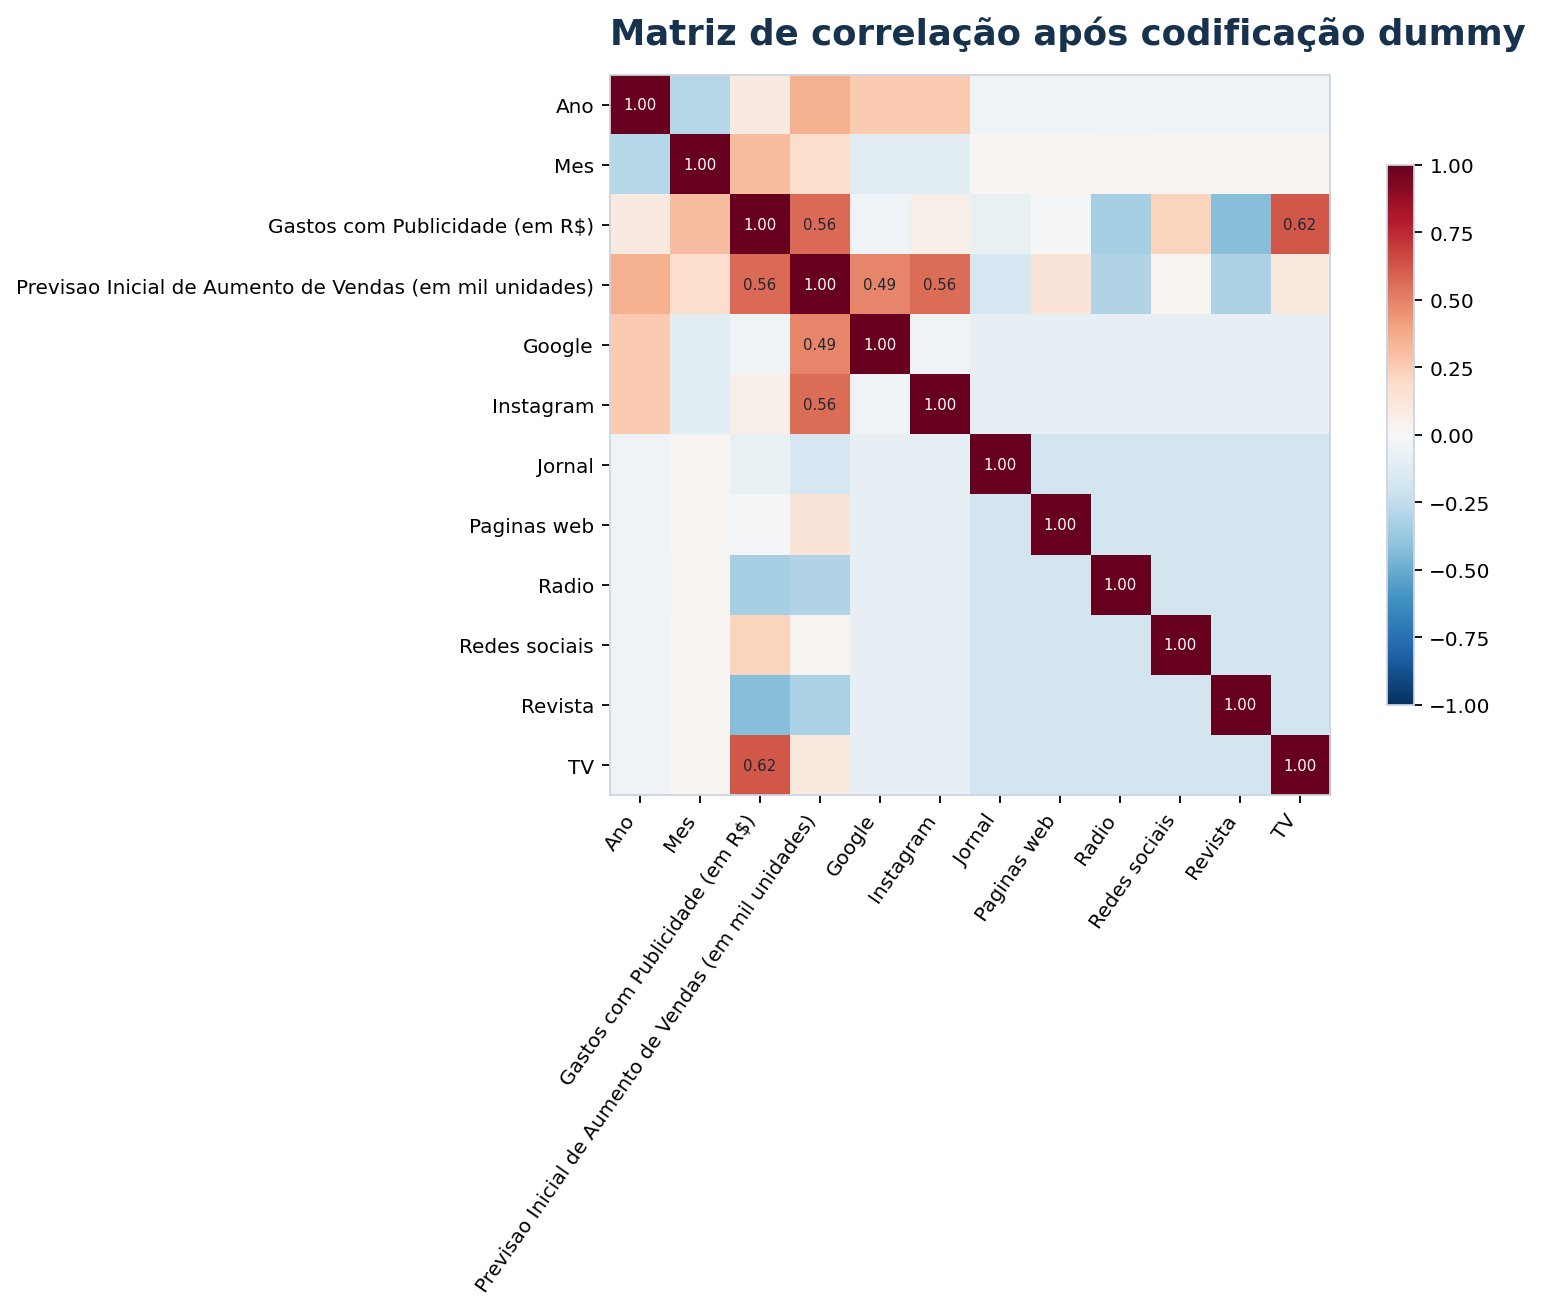

In [4]:
dados_correlacao = pd.get_dummies(
    dados[["Ano", "Mes", COL_MIDIA, COL_GASTO, COL_ALVO]],
    columns=[COL_MIDIA],
    dtype=float,
)
matriz_correlacao = dados_correlacao.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 8))
imagem = ax.imshow(matriz_correlacao, cmap="RdBu_r", vmin=-1, vmax=1)
rotulos = [c.replace("Tipo de Midia_", "") for c in matriz_correlacao.columns]
ax.set_xticks(range(len(rotulos)), rotulos, rotation=55, ha="right")
ax.set_yticks(range(len(rotulos)), rotulos)
for i in range(len(matriz_correlacao)):
    for j in range(len(matriz_correlacao)):
        valor = matriz_correlacao.iloc[i, j]
        if abs(valor) >= 0.45 or i == j:
            ax.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Matriz de correlação após codificação dummy", loc="left")
fig.colorbar(imagem, ax=ax, shrink=.75)
plt.tight_layout()
plt.show()

A correlação simples entre gasto e aumento previsto é moderada, pois o retorno varia fortemente por canal. Após a codificação dummy, Google e Instagram se associam positivamente ao alvo, mas sua amostra é pequena e restrita a 2024.

### 5. Gráficos de dispersão por mídia

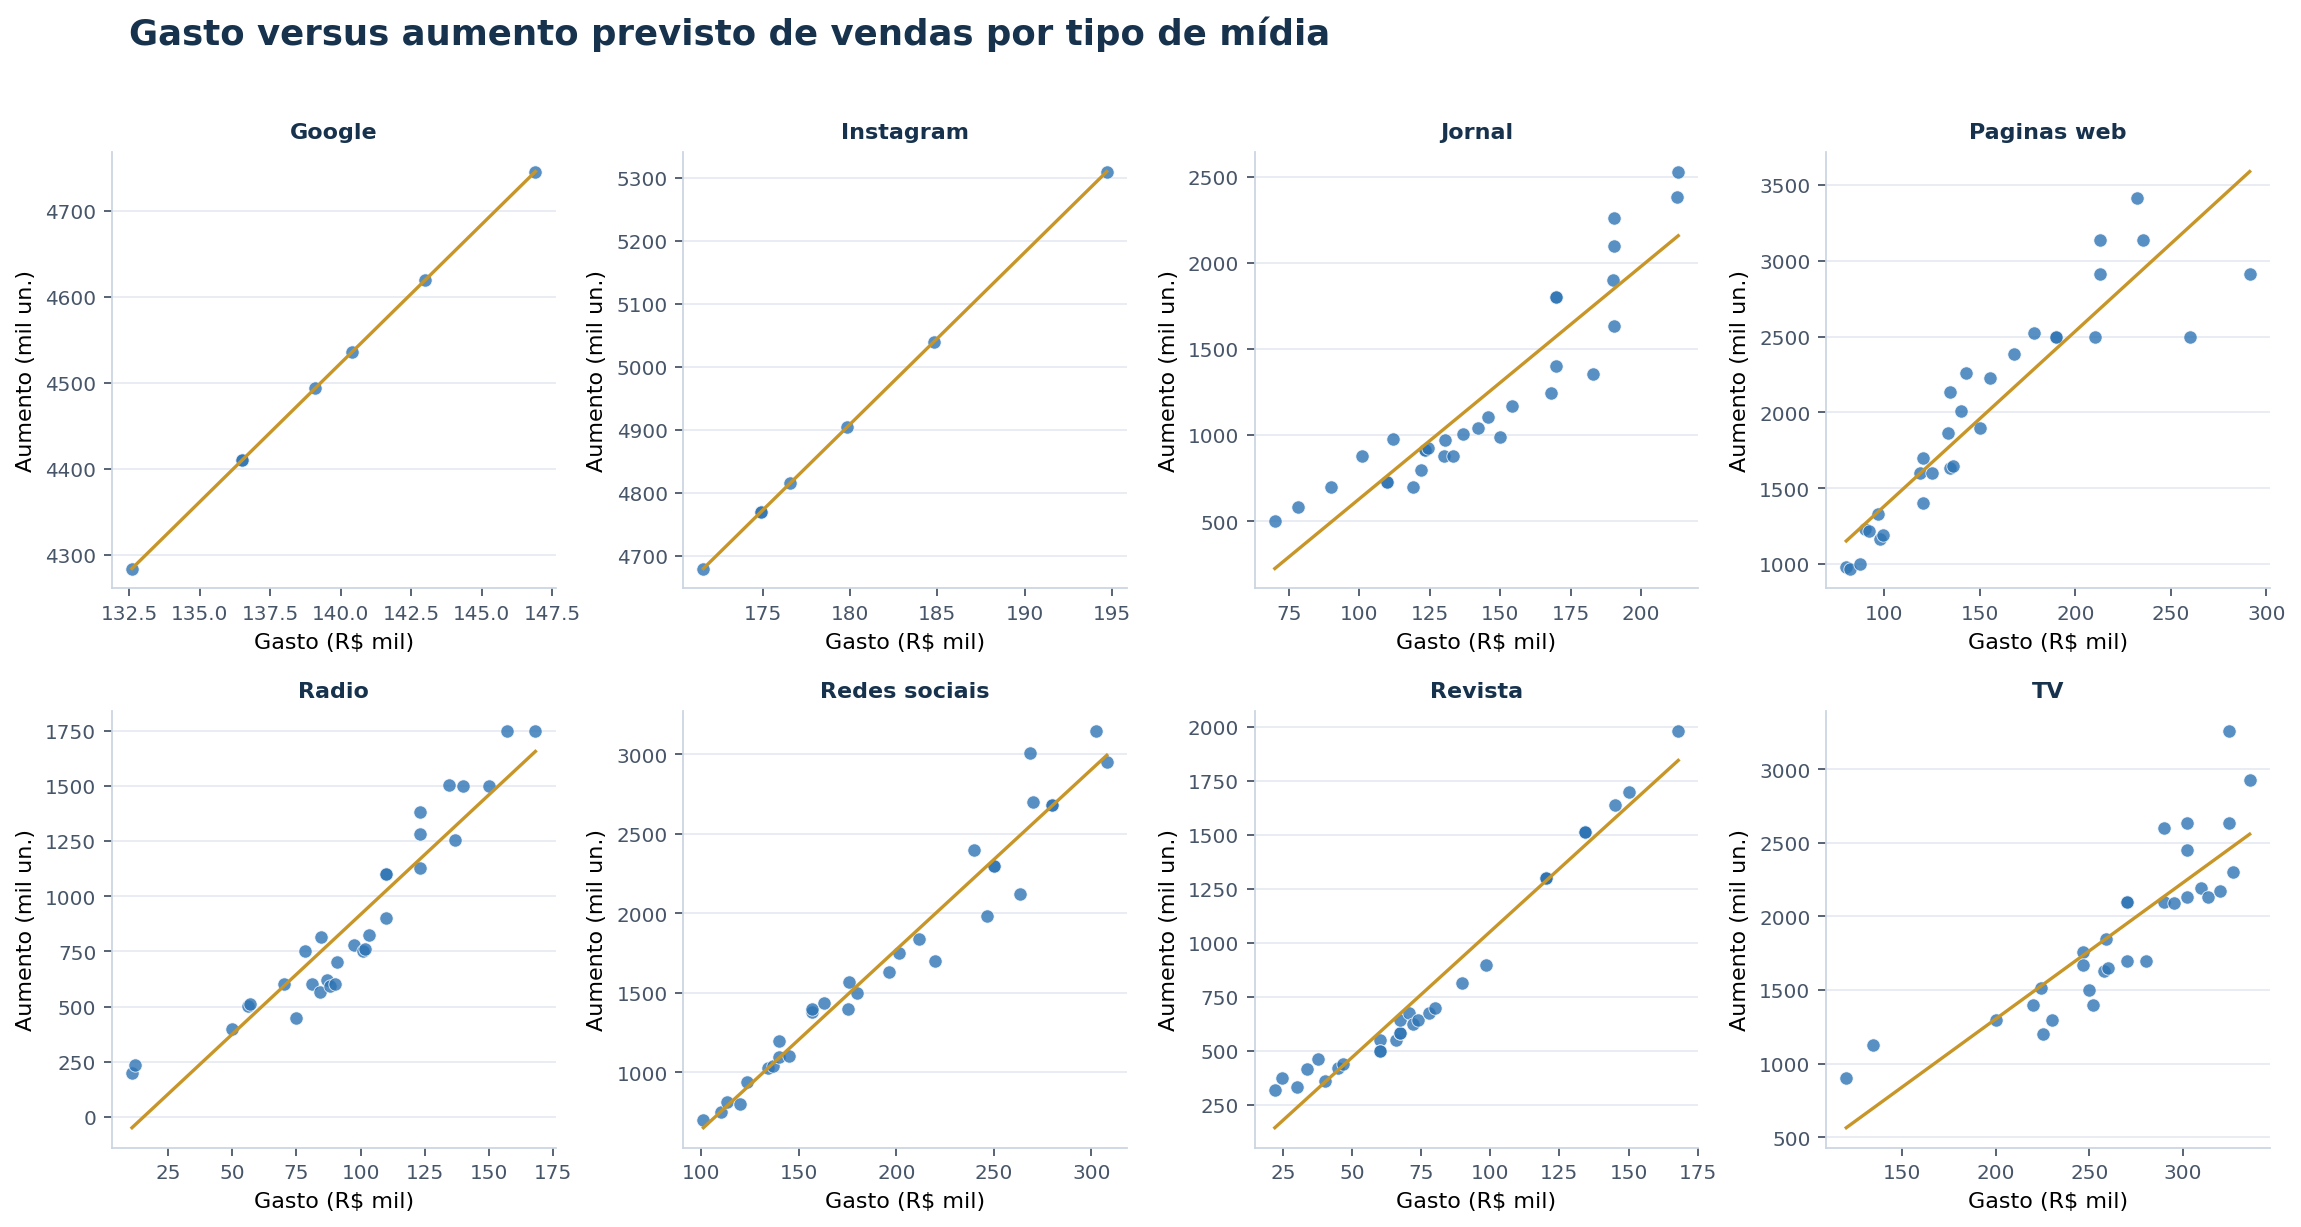

In [5]:
midias = sorted(dados[COL_MIDIA].unique())
fig, eixos = plt.subplots(2, 4, figsize=(15, 8))
for eixo, midia in zip(eixos.flat, midias):
    grupo = dados[dados[COL_MIDIA] == midia].sort_values(COL_GASTO)
    eixo.scatter(grupo[COL_GASTO] / 1000, grupo[COL_ALVO], alpha=.8)
    regressao_local = LinearRegression().fit(grupo[[COL_GASTO]], grupo[COL_ALVO])
    grade = np.linspace(grupo[COL_GASTO].min(), grupo[COL_GASTO].max(), 100)
    eixo.plot(grade / 1000, regressao_local.predict(grade.reshape(-1, 1)), color="darkorange")
    eixo.set_title(midia)
    eixo.set_xlabel("Gasto (R$ mil)")
    eixo.set_ylabel("Aumento (mil un.)")
plt.suptitle("Gasto versus aumento previsto de vendas por mídia", x=.06, ha="left")
plt.tight_layout()
plt.show()

Os oito painéis mostram relação positiva entre gasto e aumento previsto. Google e Instagram têm relação perfeitamente proporcional nos sete registros disponíveis; TV apresenta maior dispersão entre as mídias tradicionais.

### 6. Engenharia de atributos e divisão treino/teste

In [6]:
def criar_features_por_midia(df, grau=1):
    dummies = pd.get_dummies(df[COL_MIDIA], prefix="midia", dtype=float)
    X = pd.DataFrame({
        "gasto": df[COL_GASTO],
        "ano": df["Ano_c"],
        "mes": df["Mes_c"],
    }, index=df.index)
    for coluna in dummies.columns:
        X[coluna] = dummies[coluna]
        X[f"gasto_x_{coluna}"] = df[COL_GASTO] * dummies[coluna]
        if grau >= 2:
            X[f"gasto2_x_{coluna}"] = (df[COL_GASTO] ** 2) * dummies[coluna]
        if grau >= 3:
            X[f"gasto3_x_{coluna}"] = (df[COL_GASTO] ** 3) * dummies[coluna]
    return X

y = dados[COL_ALVO]
idx_treino, idx_teste = train_test_split(
    np.arange(len(dados)), test_size=0.20, random_state=RANDOM_STATE,
    stratify=dados[COL_MIDIA]
)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"Treino: {len(idx_treino)} observações | Teste: {len(idx_teste)} observações")

Treino: 160 observações | Teste: 40 observações


### 7. Comparação dos modelos

In [7]:
comparacao = []

X_original = dados[[COL_GASTO, COL_MIDIA, "Ano_c", "Mes_c"]]
modelos_base = [
    (
        "Gasto apenas",
        Pipeline([
            ("preparo", ColumnTransformer([("numerico", "passthrough", [COL_GASTO])], remainder="drop")),
            ("regressao", LinearRegression()),
        ]),
    ),
    (
        "Gasto + dummies de mídia",
        Pipeline([
            ("preparo", ColumnTransformer([
                ("numerico", "passthrough", [COL_GASTO]),
                ("categorico", OneHotEncoder(handle_unknown="ignore"), [COL_MIDIA]),
            ], remainder="drop")),
            ("regressao", LinearRegression()),
        ]),
    ),
]

for nome, modelo in modelos_base:
    modelo.fit(X_original.iloc[idx_treino], y.iloc[idx_treino])
    previsao = modelo.predict(X_original.iloc[idx_teste])
    r2_cv = cross_val_score(modelo, X_original, y, cv=cv, scoring="r2")
    comparacao.append({
        "Modelo": nome,
        "R2_teste": r2_score(y.iloc[idx_teste], previsao),
        "MAE": mean_absolute_error(y.iloc[idx_teste], previsao),
        "RMSE": math.sqrt(mean_squared_error(y.iloc[idx_teste], previsao)),
        "R2_CV_medio": r2_cv.mean(),
        "R2_CV_desvio": r2_cv.std(),
    })

modelos_com_interacao = [
    ("Linear com inclinações por mídia", 1),
    ("Polinomial grau 2 por mídia", 2),
    ("Polinomial grau 3 por mídia", 3),
]

for nome, grau in modelos_com_interacao:
    X = criar_features_por_midia(dados, grau)
    modelo = Pipeline([
        ("escala", StandardScaler()),
        ("regressao", LinearRegression()),
    ])
    modelo.fit(X.iloc[idx_treino], y.iloc[idx_treino])
    previsao = modelo.predict(X.iloc[idx_teste])
    r2_cv = cross_val_score(modelo, X, y, cv=cv, scoring="r2")
    comparacao.append({
        "Modelo": nome,
        "R2_teste": r2_score(y.iloc[idx_teste], previsao),
        "MAE": mean_absolute_error(y.iloc[idx_teste], previsao),
        "RMSE": math.sqrt(mean_squared_error(y.iloc[idx_teste], previsao)),
        "R2_CV_medio": r2_cv.mean(),
        "R2_CV_desvio": r2_cv.std(),
    })

comparacao_modelos = pd.DataFrame(comparacao).sort_values("R2_CV_medio", ascending=False)
print(comparacao_modelos.round(4).to_string(index=False))

                          Modelo  R2_teste      MAE      RMSE  R2_CV_medio  R2_CV_desvio
     Polinomial grau 2 por mídia    0.9858 106.2009  138.7980       0.9734        0.0110
     Polinomial grau 3 por mídia    0.9841 113.0843  147.0885       0.9679        0.0131
Linear com inclinações por mídia    0.9753 137.9661  183.4178       0.9631        0.0156
        Gasto + dummies de mídia    0.9789 134.3914  169.3084       0.9500        0.0107
                    Gasto apenas    0.2193 626.6582 1030.7703       0.3239        0.1036


O grau 3 obtém ajuste ligeiramente maior dentro da amostra, mas piora na validação cruzada. O grau 2 é escolhido para reduzir o risco de overfitting e manter melhor capacidade de generalização.

### 8. Avaliação do modelo final

R² teste: 0.9858
MAE: 106.20 mil unidades
RMSE: 138.80 mil unidades


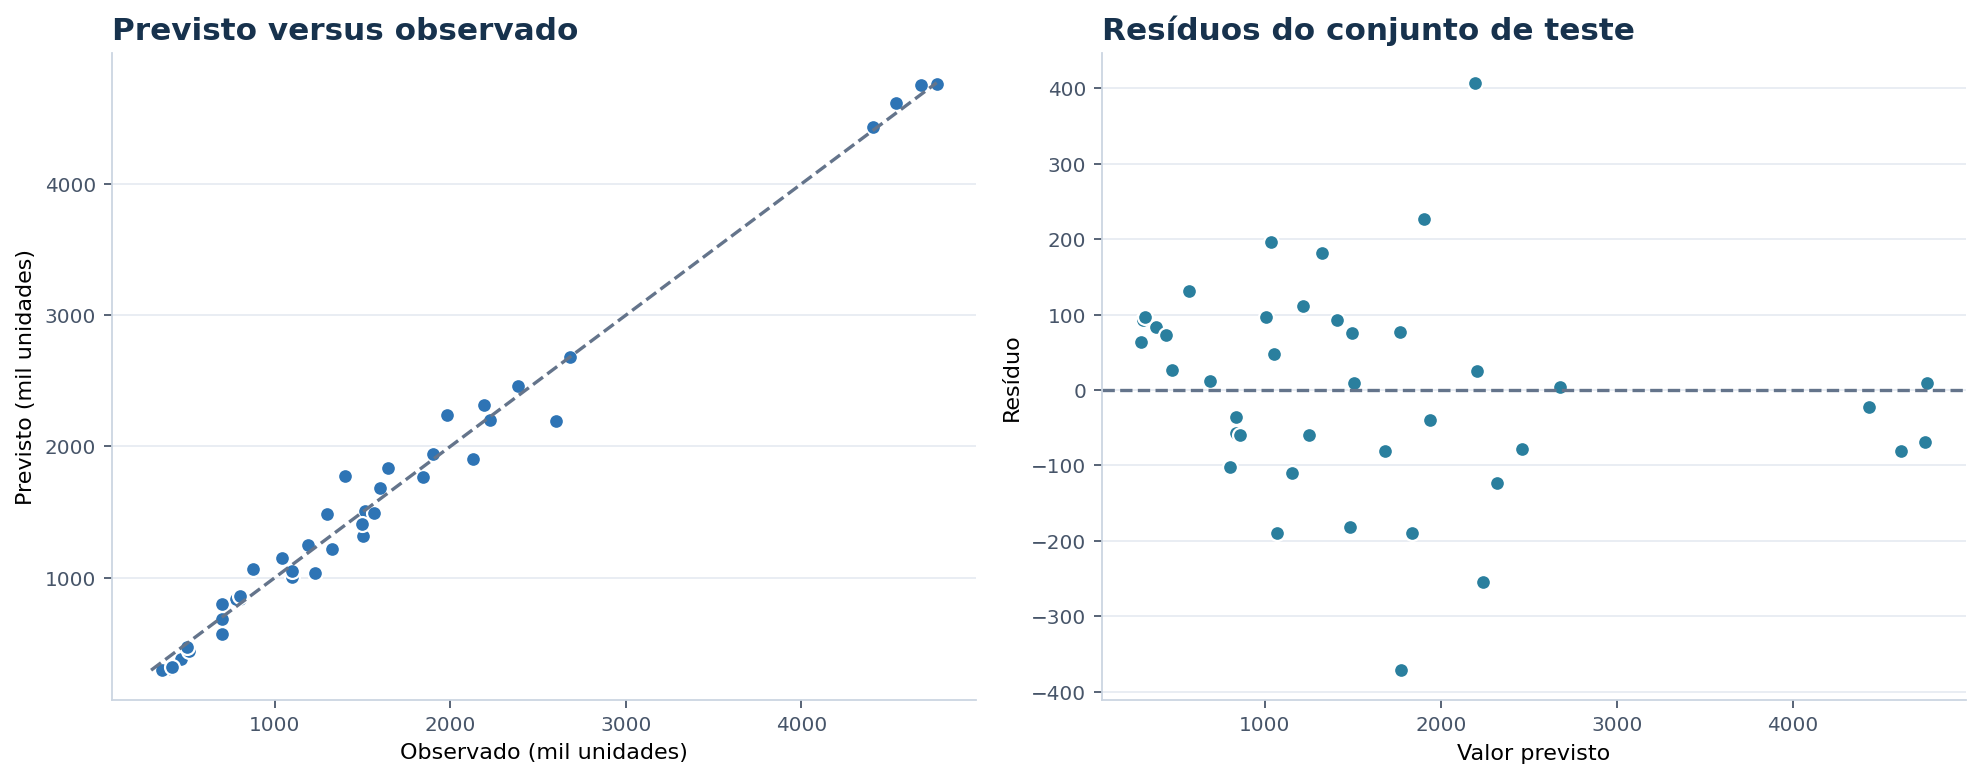

In [8]:
X_final = criar_features_por_midia(dados, grau=2)
modelo_final = Pipeline([
    ("escala", StandardScaler()),
    ("regressao", LinearRegression()),
])
modelo_final.fit(X_final.iloc[idx_treino], y.iloc[idx_treino])
prev_teste = modelo_final.predict(X_final.iloc[idx_teste])
residuos = y.iloc[idx_teste] - prev_teste

r2_final = r2_score(y.iloc[idx_teste], prev_teste)
mae_final = mean_absolute_error(y.iloc[idx_teste], prev_teste)
rmse_final = math.sqrt(mean_squared_error(y.iloc[idx_teste], prev_teste))
print(f"R² teste: {r2_final:.4f}")
print(f"MAE: {mae_final:.2f} mil unidades")
print(f"RMSE: {rmse_final:.2f} mil unidades")

fig, eixos = plt.subplots(1, 2, figsize=(13, 5))
eixos[0].scatter(y.iloc[idx_teste], prev_teste)
limites = [min(y.iloc[idx_teste].min(), prev_teste.min()), max(y.iloc[idx_teste].max(), prev_teste.max())]
eixos[0].plot(limites, limites, "--", color="gray")
eixos[0].set(xlabel="Observado", ylabel="Previsto", title="Previsto versus observado")
eixos[1].scatter(prev_teste, residuos)
eixos[1].axhline(0, linestyle="--", color="gray")
eixos[1].set(xlabel="Previsto", ylabel="Resíduo", title="Resíduos no teste")
plt.tight_layout()
plt.show()

### 9. Eficiência observada por mídia

In [9]:
eficiencia = (
    dados.assign(Eficiencia_por_100_mil=dados[COL_ALVO] / dados[COL_GASTO] * 100_000)
    .groupby(COL_MIDIA)["Eficiencia_por_100_mil"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)
print(eficiencia.round(2).to_string())
print("\nImportante: a base informa aumento previsto em unidades, não receita ou margem incremental.")
print("Por isso, esta eficiência não é ROI financeiro completo; ela mede unidades previstas por R$ 100 mil investidos.")

               count     mean   median     std
Tipo de Midia                                 
Google             7  3230.77  3230.77    0.00
Instagram          7  2727.27  2727.27    0.00
Paginas web       31  1311.04  1325.13  146.16
Revista           31  1024.16   955.22  176.84
Radio             31   940.86   896.43  284.98
Redes sociais     31   853.54   857.14  109.05
Jornal            31   818.61   743.54  170.29
TV                31   714.26   705.16  108.12

Importante: a base informa aumento previsto em unidades, não receita ou margem incremental.
Por isso, esta eficiência não é ROI financeiro completo; ela mede unidades previstas por R$ 100 mil investidos.


## Takeaways

1. **Usar mídia e interação gasto × mídia é indispensável.** O modelo que usa somente gasto perde a diferença estrutural de retorno entre canais.
2. **Google e Instagram lideram a eficiência observada**, seguidos por Páginas web. Entretanto, os dois primeiros possuem somente sete observações e não devem receber todo o orçamento sem teste incremental.
3. **O modelo de grau 2 é a melhor escolha prática**: apresenta R² alto no teste e a melhor média na validação cruzada, enquanto o grau 3 adiciona complexidade sem ganho fora da amostra.
4. **A análise é preditiva, não causal.** Os dados não provam que a mídia causou o aumento previsto; fatores de campanha, produto e sazonalidade podem estar omitidos.
5. **Recomendação ao marketing:** ampliar experimentos em Google e Instagram, preservar Páginas web como canal de eficiência relevante e coletar receita/margem incremental para calcular ROI financeiro verdadeiro.
